In [2]:
!pip install timm==0.9.12

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 54.3 MB/s eta 0:00:00
  Attempting uninstall: timm
    Found existing installation: timm 1.0.26
    Uninstalling timm-1.0.26:
      Successfully uninstalled timm-1.0.26


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import timm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import *
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE

plt.style.use('seaborn-v0_8-whitegrid')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
data_root = "/content/drive/MyDrive/Teeth_Dataset"

train_dataset = datasets.ImageFolder(f"{data_root}/Training")
val_dataset   = datasets.ImageFolder(f"{data_root}/Validation")
test_dataset  = datasets.ImageFolder(f"{data_root}/Testing")

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)

Classes: ['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']


In [ ]:
transform_train = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomResizedCrop(224, scale=(0.8,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.3,0.3,0.3,0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])


train_dataset.transform = transform_train
val_dataset.transform   = transform_test
test_dataset.transform  = transform_test

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

In [6]:
class EfficientNetBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        base = torchvision.models.efficientnet_b0(pretrained=True)
        self.features = base.features

    def forward(self,x):
        x = self.features[0](x)
        x = self.features[1](x)
        F1 = self.features[2](x)
        F2 = self.features[3](F1)
        F3 = self.features[4:](F2)
        return F1,F2,F3


class ViTBranch(nn.Module):
    def __init__(self):
        super().__init__()
        self.vit = timm.create_model('vit_small_patch16_224', pretrained=True, num_classes=0)

    def forward(self,x):
        tokens = self.vit.forward_features(x)
        return tokens[:,0]


class FeatureFusionAttention(nn.Module):
    def __init__(self, cnn_dim, vit_dim, num_classes):
        super().__init__()

        self.cnn_aux = nn.Linear(cnn_dim, num_classes)
        self.vit_aux = nn.Linear(vit_dim, num_classes)

        self.proj = nn.Linear(cnn_dim + vit_dim, 512)
        self.attn_dense = nn.Linear(512, 128)
        self.attn_score = nn.Linear(128, 512)

    def forward(self, h_cnn, h_vit):
        cnn_logits = self.cnn_aux(h_cnn)
        vit_logits = self.vit_aux(h_vit)

        fused = torch.cat([h_cnn, h_vit], dim=1)
        fused = F.relu(self.proj(fused))

        attn = F.relu(self.attn_dense(fused))
        attn = F.softmax(self.attn_score(attn), dim=1)

        fused = fused * attn
        return fused, cnn_logits, vit_logits


class OrCanNet(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.cnn = EfficientNetBackbone()
        self.vit = ViTBranch()
        self.fusion = FeatureFusionAttention(1280,384,num_classes)
        self.dropout = nn.Identity()
        self.classifier = nn.Linear(512,num_classes)

    def forward(self,x):
        _,_,F3 = self.cnn(x)
        h_cnn = torch.flatten(F.adaptive_avg_pool2d(F3,1),1)
        h_vit = self.vit(x)

        fused,cnn_logits,vit_logits = self.fusion(h_cnn,h_vit)
        fused = self.dropout(fused)

        out = self.classifier(fused)
        return out,cnn_logits,vit_logits,fused


model = OrCanNet(num_classes).to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 57.2MB/s]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

In [7]:
model = OrCanNet(num_classes).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
epochs = 30

train_losses, val_losses = [], []
train_accs, val_accs = [], []

In [8]:
epoch_times = []
cumulative_times = []
throughputs = []

start_training_time = time.time()

In [9]:
def compute_loss(out, cnn_logits, vit_logits, labels):
    main = F.cross_entropy(out, labels)
    aux1 = F.cross_entropy(cnn_logits, labels)
    aux2 = F.cross_entropy(vit_logits, labels)
    return main, aux1, aux2

In [10]:
train_f1s, val_f1s = [], []
main_losses, cnn_losses, vit_losses = [], [], []
grad_norms, lr_history = [], []

In [ ]:
# --- ADD THESE ABOVE LOOP ---
epoch_times = []
cumulative_times = []
throughputs = []
start_training_time = time.time()
num_train_samples = len(train_loader.dataset)


for epoch in range(epochs):

    epoch_start = time.time()
    model.train()

    tl, correct, total = 0, 0, 0
    preds_all, labels_all = [], []

    main_l, cnn_l, vit_l = 0, 0, 0

    # ---------------- TRAIN ----------------
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out, cnn_logits, vit_logits, _ = model(x)

        m, a1, a2 = compute_loss(out, cnn_logits, vit_logits, y)

        loss = m   # or: m + 0.1*(a1+a2)

        loss.backward()

        total_norm = 0
        for p in model.parameters():
            if p.grad is not None:
                param_norm = p.grad.data.norm(2)
                total_norm += param_norm.item() ** 2
        grad_norms.append(total_norm ** 0.5)

        optimizer.step()
        lr_history.append(optimizer.param_groups[0]['lr'])

        tl += loss.item()
        main_l += m.item()
        cnn_l += a1.item()
        vit_l += a2.item()

        preds = out.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)

        preds_all.extend(preds.cpu().numpy())
        labels_all.extend(y.cpu().numpy())

    train_losses.append(tl / len(train_loader))
    train_accs.append(correct / total)
    train_f1s.append(f1_score(labels_all, preds_all, average='macro'))

    main_losses.append(main_l / len(train_loader))
    cnn_losses.append(cnn_l / len(train_loader))
    vit_losses.append(vit_l / len(train_loader))

    # ---------------- VALIDATION ----------------
    model.eval()
    vl, correct_val, total_val = 0, 0, 0
    preds_all, labels_all = [], []

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            out, _, _, _ = model(x)

            loss = F.cross_entropy(out, y)
            vl += loss.item()

            preds = out.argmax(1)
            correct_val += (preds == y).sum().item()
            total_val += y.size(0)

            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(y.cpu().numpy())

    val_losses.append(vl / len(val_loader))
    val_accs.append(correct_val / total_val)
    val_f1s.append(f1_score(labels_all, preds_all, average='macro'))

    # ---------------- TIME METRICS ----------------
    epoch_time = time.time() - epoch_start
    epoch_times.append(epoch_time)

    cumulative_time = time.time() - start_training_time
    cumulative_times.append(cumulative_time)

    throughput = num_train_samples / epoch_time
    throughputs.append(throughput)

    # ---------------- LOG ----------------
    print(f"Epoch {epoch+1:02d} | "
          f"Train Acc: {train_accs[-1]:.4f} | "
          f"Val Acc: {val_accs[-1]:.4f} | "
          f"Train F1: {train_f1s[-1]:.4f} | "
          f"Val F1: {val_f1s[-1]:.4f} | "
          f"Loss: {train_losses[-1]:.4f} | "
          f"Time: {epoch_time:.2f}s | "
          f"Throughput: {throughput:.2f}/s")

Epoch 01 | Train Acc: 0.3583 | Val Acc: 0.4718 | Train F1: 0.3095 | Val F1: 0.3693 | Loss: 1.6595 | Time: 1486.78s | Throughput: 2.08/s
Epoch 02 | Train Acc: 0.4610 | Val Acc: 0.5691 | Train F1: 0.4237 | Val F1: 0.4931 | Loss: 1.2254 | Time: 75.91s | Throughput: 40.66/s
Epoch 03 | Train Acc: 0.5549 | Val Acc: 0.6002 | Train F1: 0.4720 | Val F1: 0.4555 | Loss: 1.0298 | Time: 74.73s | Throughput: 41.31/s
Epoch 04 | Train Acc: 0.5999 | Val Acc: 0.6751 | Train F1: 0.4959 | Val F1: 0.5839 | Loss: 0.8803 | Time: 75.14s | Throughput: 41.08/s
Epoch 05 | Train Acc: 0.6987 | Val Acc: 0.8298 | Train F1: 0.6321 | Val F1: 0.7616 | Loss: 0.7200 | Time: 74.91s | Throughput: 41.21/s
Epoch 06 | Train Acc: 0.7729 | Val Acc: 0.7831 | Train F1: 0.7148 | Val F1: 0.7364 | Loss: 0.6140 | Time: 75.80s | Throughput: 40.73/s
Epoch 07 | Train Acc: 0.8202 | Val Acc: 0.8706 | Train F1: 0.7741 | Val F1: 0.8391 | Loss: 0.4986 | Time: 75.13s | Throughput: 41.09/s
Epoch 08 | Train Acc: 0.8552 | Val Acc: 0.8872 | Train

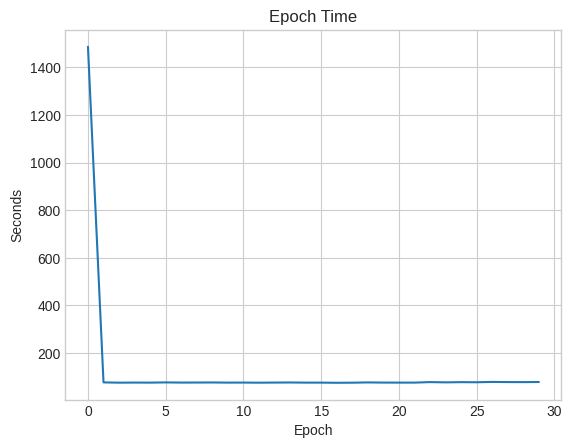

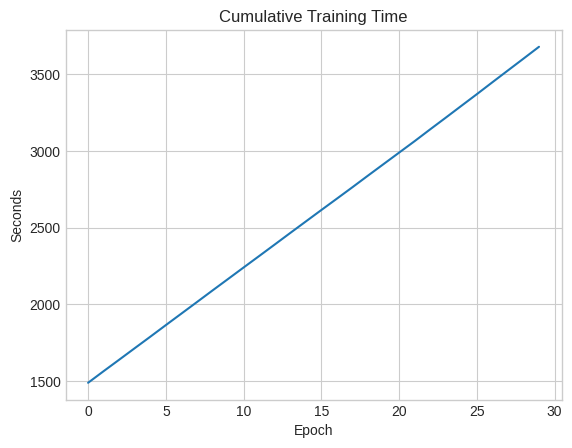

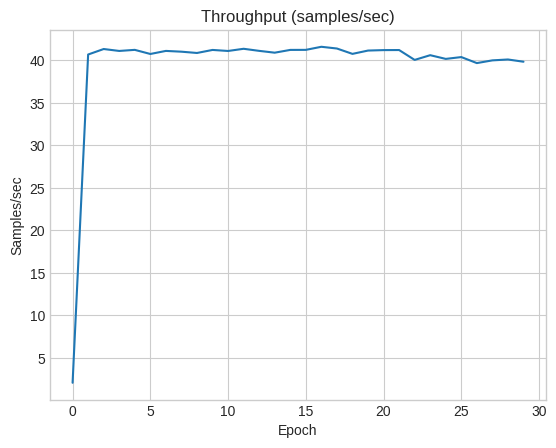

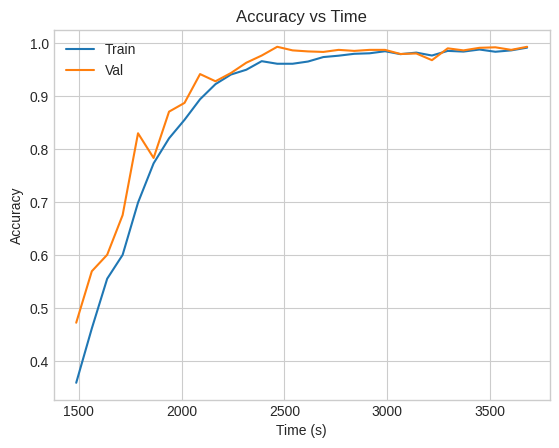

In [12]:
plt.figure()
plt.plot(epoch_times)
plt.title("Epoch Time")
plt.xlabel("Epoch")
plt.ylabel("Seconds")
plt.show()

plt.figure()
plt.plot(cumulative_times)
plt.title("Cumulative Training Time")
plt.xlabel("Epoch")
plt.ylabel("Seconds")
plt.show()

plt.figure()
plt.plot(throughputs)
plt.title("Throughput (samples/sec)")
plt.xlabel("Epoch")
plt.ylabel("Samples/sec")
plt.show()

plt.figure()
plt.plot(cumulative_times, train_accs, label="Train")
plt.plot(cumulative_times, val_accs, label="Val")
plt.legend()
plt.title("Accuracy vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Accuracy")
plt.show()

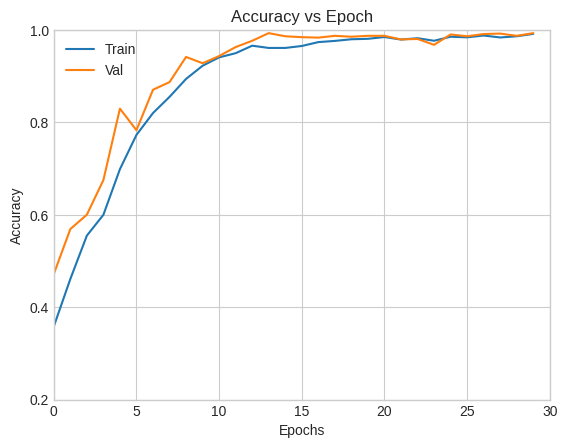

In [13]:
plt.figure()
plt.plot(train_accs,label="Train")
plt.plot(val_accs,label="Val")

plt.ylim(0.2,1.0)
plt.yticks([0.2,0.4,0.6,0.8,1.0])

plt.xlim(0, epochs)
plt.xticks(range(0, epochs+1, 5))

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.show()

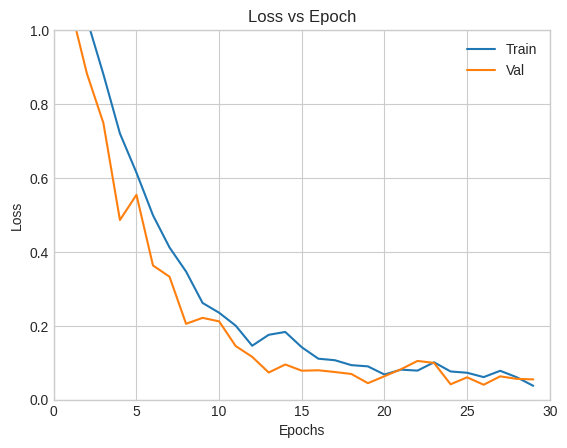

In [14]:
plt.figure()
plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Val")

plt.ylim(0,1)
plt.yticks([0,0.2,0.4,0.6,0.8,1.0])

plt.xlim(0, epochs)
plt.xticks(range(0, epochs+1, 5))

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.show()

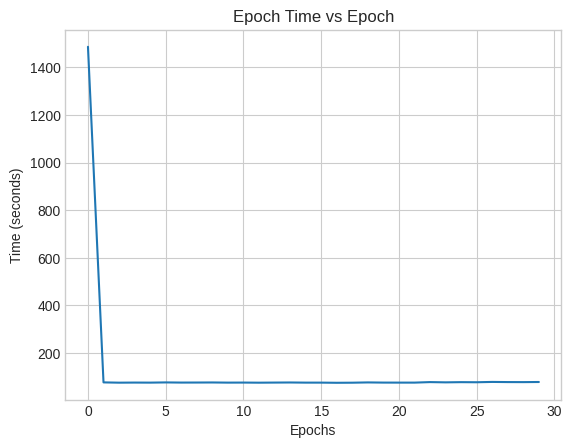

In [15]:
plt.figure()
plt.plot(epoch_times)
plt.xlabel("Epochs")
plt.ylabel("Time (seconds)")
plt.title("Epoch Time vs Epoch")
plt.show()

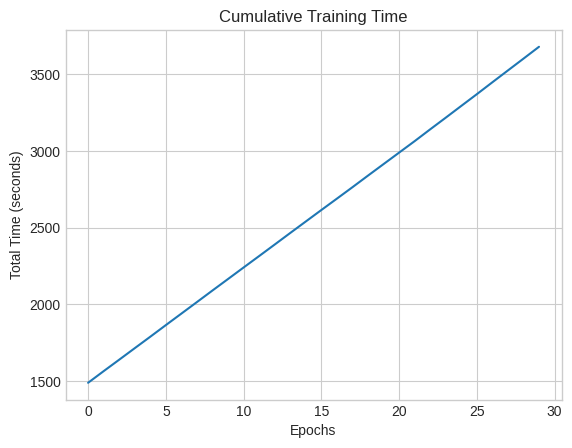

In [16]:
plt.figure()
plt.plot(cumulative_times)
plt.xlabel("Epochs")
plt.ylabel("Total Time (seconds)")
plt.title("Cumulative Training Time")
plt.show()

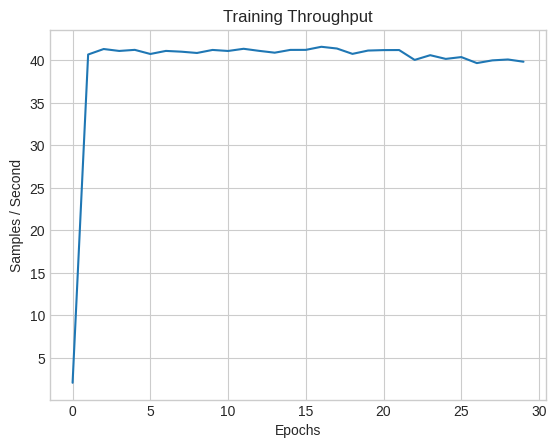

In [17]:
plt.figure()
plt.plot(throughputs)
plt.xlabel("Epochs")
plt.ylabel("Samples / Second")
plt.title("Training Throughput")
plt.show()

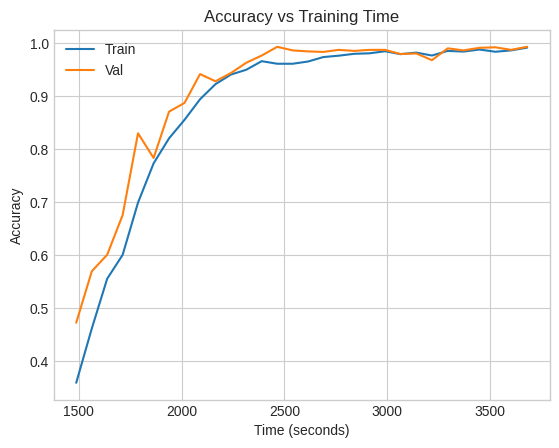

In [18]:
plt.figure()
plt.plot(cumulative_times, train_accs, label="Train")
plt.plot(cumulative_times, val_accs, label="Val")

plt.xlabel("Time (seconds)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Training Time")
plt.legend()
plt.show()

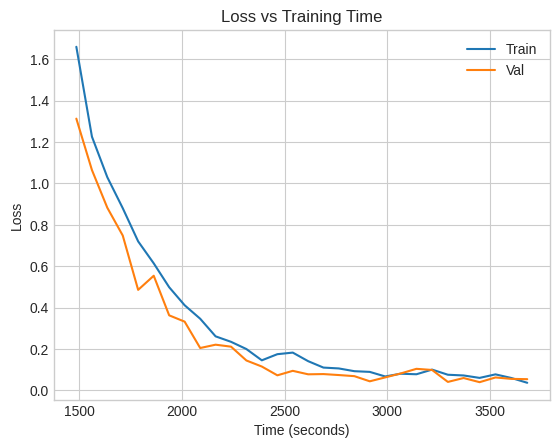

In [19]:
plt.figure()
plt.plot(cumulative_times, train_losses, label="Train")
plt.plot(cumulative_times, val_losses, label="Val")

plt.xlabel("Time (seconds)")
plt.ylabel("Loss")
plt.title("Loss vs Training Time")
plt.legend()
plt.show()

In [20]:
# Save
torch.save(model.state_dict(), "/content/drive/MyDrive/orcanet_model.pth")

# Load
model.load_state_dict(torch.load("/content/drive/MyDrive/orcanet_model.pth"))
model.eval()

OrCanNet(
  (cnn): EfficientNetBackbone(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
              (scale_

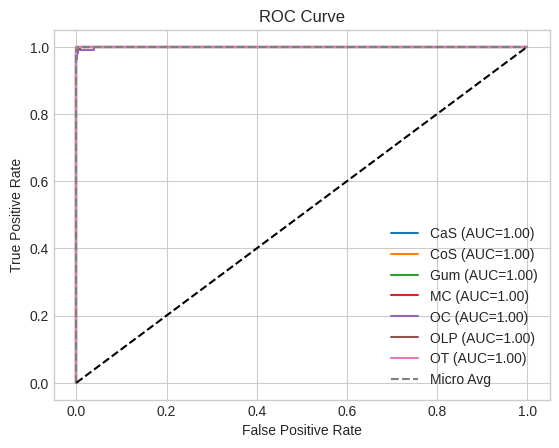

In [21]:
model.eval()
all_probs, all_labels = [], []

with torch.no_grad():
    for x,y in test_loader:
        x = x.to(device)
        out,_,_,_= model(x)

        probs = torch.softmax(out,1).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(y.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

y_bin = label_binarize(all_labels, classes=list(range(num_classes)))

plt.figure()

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:,i], all_probs[:,i])
    auc_score = roc_auc_score(y_bin[:,i], all_probs[:,i])
    plt.plot(fpr,tpr,label=f"{class_names[i]} (AUC={auc_score:.2f})")

# Micro-average
fpr_micro, tpr_micro, _ = roc_curve(y_bin.ravel(), all_probs.ravel())
plt.plot(fpr_micro, tpr_micro, linestyle='--', label="Micro Avg")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

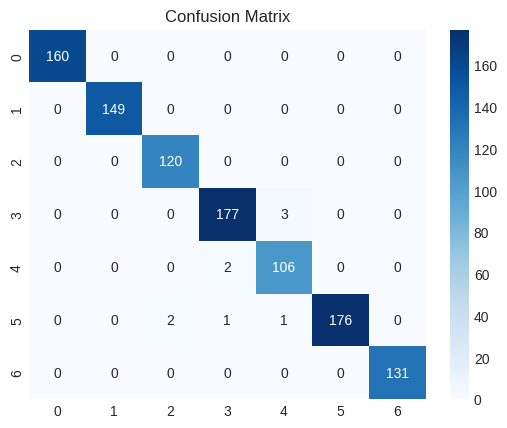

In [22]:
preds = np.argmax(all_probs,1)
cm = confusion_matrix(all_labels,preds)

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

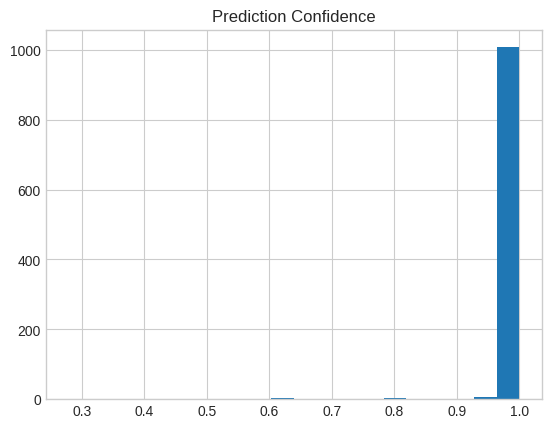

In [23]:
conf = np.max(all_probs,axis=1)
plt.hist(conf,bins=20)
plt.title("Prediction Confidence")
plt.show()

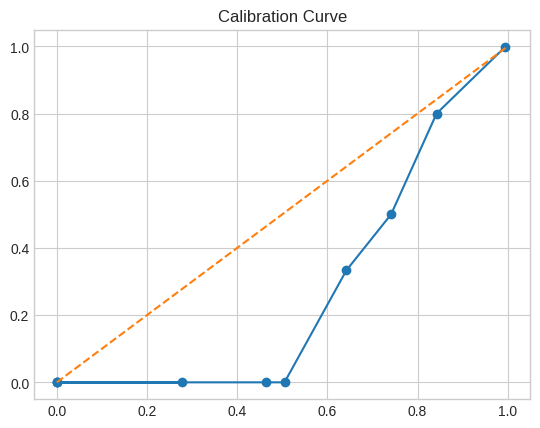

In [24]:
bins = np.linspace(0,1,11)
bin_acc, bin_conf = [], []

for i in range(10):
    idx = (conf>=bins[i]) & (conf<bins[i+1])
    if np.sum(idx)==0:
        bin_acc.append(0)
        bin_conf.append(0)
    else:
        bin_acc.append(np.mean(preds[idx]==all_labels[idx]))
        bin_conf.append(np.mean(conf[idx]))

plt.plot(bin_conf, bin_acc, marker='o')
plt.plot([0,1],[0,1],'--')
plt.title("Calibration Curve")
plt.show()

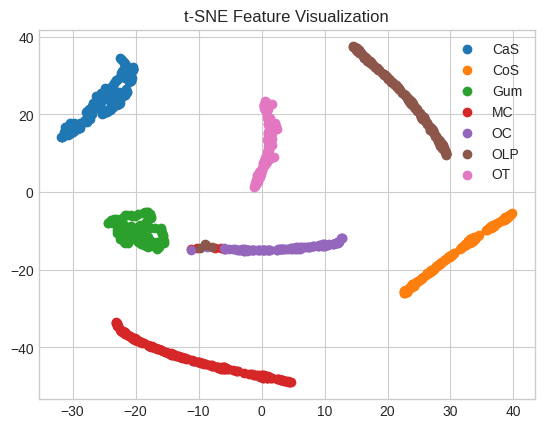

In [25]:
features = []

with torch.no_grad():
    for x,_ in test_loader:
        x = x.to(device)
        _, _, _, f = model(x)
        features.extend(f.cpu().numpy())

features = np.array(features)

proj = TSNE(n_components=2).fit_transform(features)

plt.figure()
for i in range(num_classes):
    idx = all_labels==i
    plt.scatter(proj[idx,0],proj[idx,1],label=class_names[i])

plt.legend()
plt.title("t-SNE Feature Visualization")
plt.show()